# Homework 6: The Bootstrap and Missing Data

BEE 4850/5850, Spring 2026

**Name**:

**ID**:

> **Due Date**
>
> Friday, 5/01/26, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice model evaluation and
using cross-validation and information criteria to distinguish between
models.

- Problem 1 asks you to use the parametric bootstrap to estimate
  uncertainty in a Poisson regression model.
- Problem 2 asks you to use a moving block bootstrap to estimate the
  sampling distribution of the median of extreme water level data.
- Problem 3 asks you to analyze the mechanism by which data is missing
  in a dataset.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [64]:
import Pkg
Pkg.add("GLM")
Pkg.activate(@__DIR__)
Pkg.Registry.update()
Pkg.resolve()
Pkg.instantiate()
Pkg.precompile()


   Resolving package versions...
     Project No packages added to or removed from `C:\Users\nicho\Documents\hw06-NickZajac56\Project.toml`
    Manifest No packages added to or removed from `C:\Users\nicho\Documents\hw06-NickZajac56\Manifest.toml`
  Activating project at `c:\Users\nicho\Documents\hw06-NickZajac56`
    Updating registry at `C:\Users\nicho\.julia\registries\General.toml`
     Project No packages added to or removed from `C:\Users\nicho\Documents\hw06-NickZajac56\Project.toml`
    Manifest No packages added to or removed from `C:\Users\nicho\Documents\hw06-NickZajac56\Manifest.toml`


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [65]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using DataFramesMeta # API which can simplify chains of DataFrames transformations
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization package for model fitting
using Dates # API for date-time data structures
using GLM

## Problems

### Scoring

- Problem 1 is worth 10 points;
- Problem 2 is worth 10 points;
- Problem 3 is worth 5 points


### Problem 1

Revisit the salamander model from [Homework
2](https://envdata.viveks.me/spring2026/hw/hw02.html), using percent
groundcover as a predictor in the Poisson regression. Use the
non-parametric bootstrap to estimate bias and confidence intervals for
the model parameters.

#### Problem 1.1

Load the data from `data/salamanders.csv` and fit a Poisson regression
model for salamander counts using the percentage of ground cover.

#### Problem 1.2

Use 1,000 parametric bootstrap samples to obtain estimates of bias and
the 90% confidence interval for the intercept and coefficient in the
Poisson regression.

#### Problem 1.3

What can you conclude about the level of uncertainty about the influence
of ground cover on the expected number of salamanders?


In [66]:
#problem 1.1

#load data
salamander = CSV.read("data/salamanders.csv", DataFrame, delim = ";")

#standardize
stdz(x) = (x .- mean(x)) / std(x)

salamander.pct_stdz = stdz(salamander.PCTCOVER)

#fit Possion regression model
model = glm(@formula(SALAMAN ~ pct_stdz), salamander, Poisson(), LogLink())

model_notstandard = glm(@formula(SALAMAN ~ PCTCOVER), salamander, Poisson(), LogLink())


StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Poisson{Float64}, LogLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

SALAMAN ~ 1 + PCTCOVER

Coefficients:
────────────────────────────────────────────────────────────────────────────
                  Coef.  Std. Error      z  Pr(>|z|)   Lower 95%   Upper 95%
────────────────────────────────────────────────────────────────────────────
(Intercept)  -1.48196    0.45578     -3.25    0.0011  -2.37527    -0.588645
PCTCOVER      0.0324095  0.00539141   6.01    <1e-08   0.0218425   0.0429764
────────────────────────────────────────────────────────────────────────────

In [67]:
#problem 1.2

n_boot = 1000

#establish predictions and get original coefficients

mu_hat = predict(model_notstandard)
coef_original = coef(model_notstandard)

#prepare boot parameter storage

boot_intercept = zeros(n_boot)
boot_slope = zeros(n_boot)

#bootstrap code

for i in 1:n_boot

    y_sim = rand.(Poisson.(mu_hat))

    salamander.SALAMAN_sim = y_sim

    model_sim = glm(@formula(SALAMAN_sim ~ PCTCOVER), salamander, Poisson(), LogLink())

    boot_intercept[i] = coef(model_sim)[1]
    boot_slope[i] = coef(model_sim)[2]
end

bias_intercept = mean(boot_intercept) - coef_original[1]
bias_slope = mean(boot_slope) - coef_original[2]

ci_intercept = quantile(boot_intercept, [0.05, 0.95])
ci_slope = quantile(boot_slope, [0.05, 0.95])

println("Original intercept: ", coef_original[1])
println("Original slope: ", coef_original[2])

println("Intercept bias: ", bias_intercept)
println("Slope bias: ", bias_slope)

println("90% CI intercept: ", ci_intercept)
println("90% CI slope: ", ci_slope)

Original intercept: -1.4819573565997732
Original slope: 0.032409461693609434
Intercept bias: -0.08503090353904863
Slope bias: 0.000875925644100585
90% CI intercept: [-2.4132347662229776, -0.8697053673697904]
90% CI slope: [0.02509747309556154, 0.043216488749167024]


Problem 1.3

I can conclude that there is some uncertainity about the influence of ground cover on the expected number of salamanders, but it is not overly significant.  The bootstrap results indicate that ground cover has a consistently positive effect on salamander counts.  This can be seen in the 90% CI slope results of (0.025, 0.045) and how it does not include 0 or a negative number.  There is also a very low slope bias as well, with it being 0.0009.  Since I used the nonstandardized model, doing e^0.0251 and e^0.0447 gives ~2.5 and 4.6%.  So, the 90% CI estimates a 2.5% to 4.6% increase in salamander count per 1% increase in ground cover.  

With the relatively narrow CI estimates, how it is an entirely positive range, and minimal bias, I can conclude that there is some uncertainity, but it does not appear to be overly-impactful.


### Problem 2

Let’s revisit the 2015 Sewell’s Point tide gauge data, which consists of
hourly observations and predicted sea-level based on NOAA’s harmonic
model.

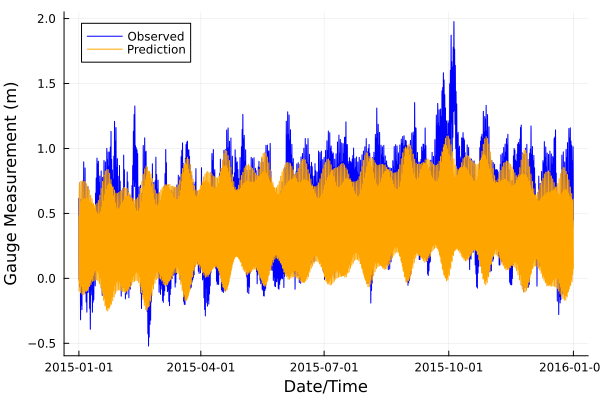

In [68]:
function load_data(fname)
    date_format = "yyyy-mm-dd HH:MM"
    # this uses the DataFramesMeta package -- it's pretty cool
    return @chain fname begin
        CSV.File(; dateformat=date_format)
        DataFrame
        rename(
            "Time (GMT)" => "time", "Predicted (m)" => "harmonic", "Verified (m)" => "gauge"
        )
        @transform :datetime = (Date.(:Date, "yyyy/mm/dd") + Time.(:time))
        select(:datetime, :gauge, :harmonic)
        @transform :weather = :gauge - :harmonic
        @transform :month = (month.(:datetime))
    end
end

dat = load_data("data/norfolk-hourly-surge-2015.csv")

plot(dat.datetime, dat.gauge; ylabel="Gauge Measurement (m)", label="Observed", legend=:topleft, xlabel="Date/Time", color=:blue)
plot!(dat.datetime, dat.harmonic, label="Prediction", color=:orange)

We detrend the data to isolate the weather-induced variability by
subtracting the predictions from the observations; the results
(following the Julia code) are in `dat[:, :weather]`.

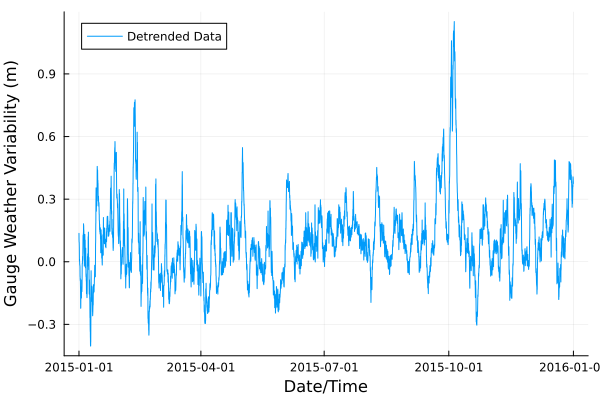

In [69]:
plot(dat.datetime, dat.weather; ylabel="Gauge Weather Variability (m)", label="Detrended Data", linewidth=1, legend=:topleft, xlabel="Date/Time")

We would like to understand the uncertainty in an estimate of the median
sea level.

#### Problem 2.1

Construct 1,000 bootstrap replicates by adding a moving block bootstrap
replicate from the weather-induced variability series (with block length
20) to the harmonic prediction. Use these replicates to compute a 90%
confidence interval. What is the bias of the estimator?

#### Problem 2.2

Repeat the analysis with block length 50. How does this affect the
confidence intervals and estimate of bias?

#### Problem 2.3

Why do you think using different block lengths produced the results that
they did?

In [70]:
Random.seed!(42)
#create a moving block bootstrap 
function mbb(series, block_len, T)

    #get total length of time series and determine number of blocks
    T = length(series)
    n_blocks = ceil(Int, T / block_len)

    result = Float64[]

    #for loop for each block
    for i in 1:n_blocks

        #Randomly pick a starting point, and then take a 
        #whole block and add it to the output

        #this builds a new time series by ranomdly taking whole blocks
        #of original data which also preserves the temporal component
        start = rand(1:(T- block_len + 1))
        append!(result, series[start:start+block_len-1])
    end

    return result[1:T]

end

#establish parameters for bootstrap code

n_b = 1000
block_len = 20

median_original = median(dat.gauge)

boot_medians = zeros(n_b)

for i in 1:n_b

    #call mbb function

    weather_bootstrap = mbb(dat.weather, block_len, length(dat.weather))

    #add the mbb replicate from the weather-induced variability series 
    #to the harmonic prediction

    gauge_bootstrap = dat.harmonic .+ weather_bootstrap
    
    boot_medians[i] = median(gauge_bootstrap)
end

#get CI and bias

ci2 = quantile(boot_medians, [0.05, 0.95])
bias2 = mean(boot_medians) - median_original

println("Original median: ", median_original)
println("Bias: ", bias2)
println("90% CI: ", ci2)

Original median: 0.508
Bias: 0.004794499999999924
90% CI: [0.498475, 0.5269999999999999]


In [71]:
#problem 2.2

Random.seed!(42)
#create a moving block bootstrap 
function mbb(series, block_len, T)

    #get total length of time series and determine number of blocks
    T = length(series)
    n_blocks = ceil(Int, T / block_len)

    result = Float64[]

    #for loop for each block
    for i in 1:n_blocks

        #Randomly pick a starting point, and then take a 
        #whole block and add it to the output

        #this builds a new time series by ranomdly taking whole blocks
        #of original data which also preserves the temporal component
        start = rand(1:(T- block_len + 1))
        append!(result, series[start:start+block_len-1])
    end

    return result[1:T]

end

#establish parameters for bootstrap code

n_b = 1000
block_len = 50

median_original = median(dat.gauge)

boot_medians = zeros(n_b)

for i in 1:n_b

    #call mbb function

    weather_bootstrap = mbb(dat.weather, block_len, length(dat.weather))

    #add the mbb replicate from the weather-induced variability series 
    #to the harmonic prediction

    gauge_bootstrap = dat.harmonic .+ weather_bootstrap
    
    boot_medians[i] = median(gauge_bootstrap)
end

#get CI and bias

ci2 = quantile(boot_medians, [0.05, 0.95])
bias2 = mean(boot_medians) - median_original

println("Original median: ", median_original)
println("Bias: ", bias2)
println("90% CI: ", ci2)

Original median: 0.508
Bias: 0.004964999999999886
90% CI: [0.49400000000000005, 0.5329999999999999]


Problem 2.2

The CI and estimate of bias for a block length of 20 were [0.498, 0.527] and 0.0047945, respectively.
The CI and estimate of bias for a block length of 50 were [0.494, 0.533] and 0.0049650, respectively.

So, increasing the block length from 20 to 50 resulted in a larger confidence interval.  The range for block length 20 was 0.029 and the range for block length 50 was 0.039.  Bias rose by approximately 0.00017, so a notably small amount. 


Problem 2.3

If I had to posit as to why these results were observed upon increasing the block length from 20 to 50, I would guess that it is because increasing the block length has a tendancy to take in more data with temporal dependence.  Having a larger block length could account for events that have prolonged durations like storms (hurricane/typhoon season), heat waves, droughts in precipitation, etc.  When taking in a larger chunk of data that has temporal dependence, it makes sense that more uncertainty was introduced.


### Problem 3

Let’s revisit the Chicago deaths dataset (`data/chicago.csv`).

#### Problem 3.1

Which variables have missing entries? How many are missing?

#### Problem 3.2

Let’s focus on `pm10median`. Based on an exploratory analysis, do you
think these data are missing completely at random, missing at random, or
missing not at random?

In [72]:
#Make it so NA is recognized as missing
chicago = CSV.read("data/chicago.csv", DataFrame; missingstring="NA")

#For loop to find number of missing entires per column
for col in names(chicago)
    
    n_missing = count(ismissing, chicago[:, col])
   
    println(col, ": ", n_missing)
   
end

Column1: 0
death: 0
pm10median: 251
pm25median: 4387
o3median: 0
so2median: 27
time: 0
tmpd: 0


Problem 3.1

pm10median, pm25median, and so2median have missing entries.  

Missing counts:

pm10median: 251
pm25median: 4387
so2median: 27

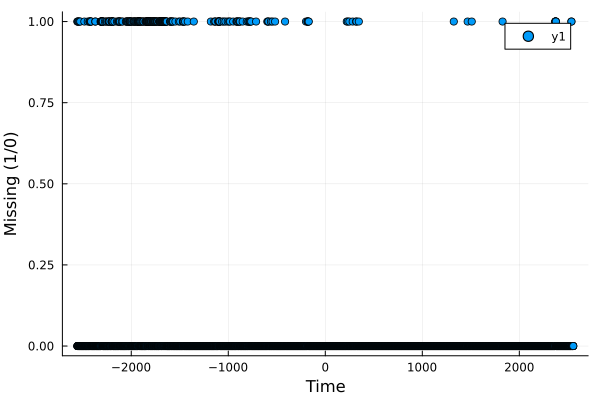

In [73]:
#Get missing pm10 readings
chicago.pm10_missing = ismissing.(chicago.pm10median)

#Compare vs time
scatter(chicago.time, chicago.pm10_missing, xlabel = "Time", ylabel = "Missing (1/0)")


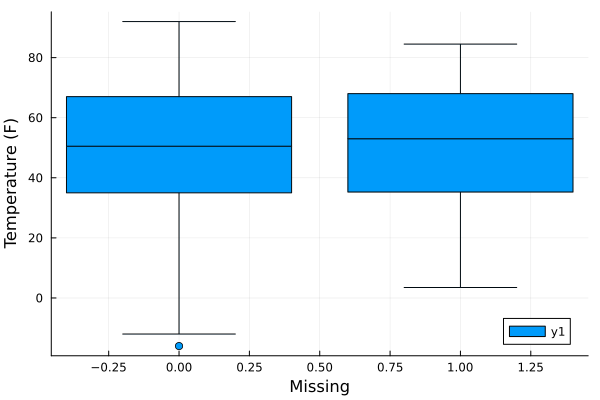

In [74]:
#Compare vs temp
boxplot(chicago.pm10_missing, chicago.tmpd, xlabel = "Missing", ylabel = "Temperature (F)")


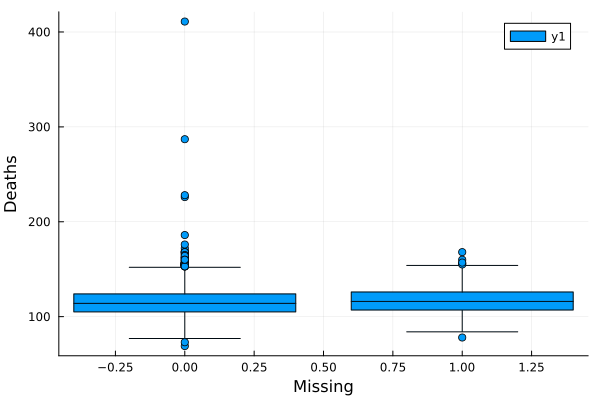

In [75]:
#Compare vs deaths
boxplot(chicago.pm10_missing, chicago.death, xlabel = "Missing", ylabel = "Deaths")

Problem 3.2

It's a bit hard for me to say, but my best guess is that since there is noticable clustering of NA's, especially at the beginning of the dataset, that it is likely not missing completely at random.  There seems to have been an external factor at play, whether that be a faulty sensor, or something else, that was causing, specifically, PM10 readings to be recorded as NA.  This is from the initial missing vs time plot.

Then, boxplots were created to check and see how the spread looked for days with missing PM10 readings, vs days without and see if there were any noticable differences.  There does not appear to be any super noticable differences in the boxplots, medians are similar across both boxplots as are the IQRs, with only the temperature boxplot showing a difference in the min and max range.

With all this being said, I think that the data is missing at random.  I think it is possible that the missingness is a result of sensor issues rather than it being completely random or it being due to the PM10 levels itself (MNAR).  The clustering, especially at the beginning, makes me think that it is not MCAR and I don't think I noticed enough for it to be MNAR.

Anecdotally, and this did not factor into my decision, I have also worked extensively with Aeroqual devices which provide real-time data for air monitoring purposes, including PM levels.  So, I have run into quite a few issues in my time with PM sensors specifically not working.  Everything else would be recording fine, wind, precipitation, VOCs, etc. except for our PM sensor which would not be malfunctioning for a variety of reasons. 

## References

OpenAI. (2024). ChatGPT (Sept 25 GPT-5 version) [Large language model].
https://chat.openai.com:  I utilized ChatGPT to help specifically with code development and some julia-specific syntax guidance.  The main ideas behind the code formulation and the actual analysis was performed by me.